In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [2]:
highalpha = pd.read_csv("highalpha.csv")
lowalpha = pd.read_csv("lowalpha.csv")

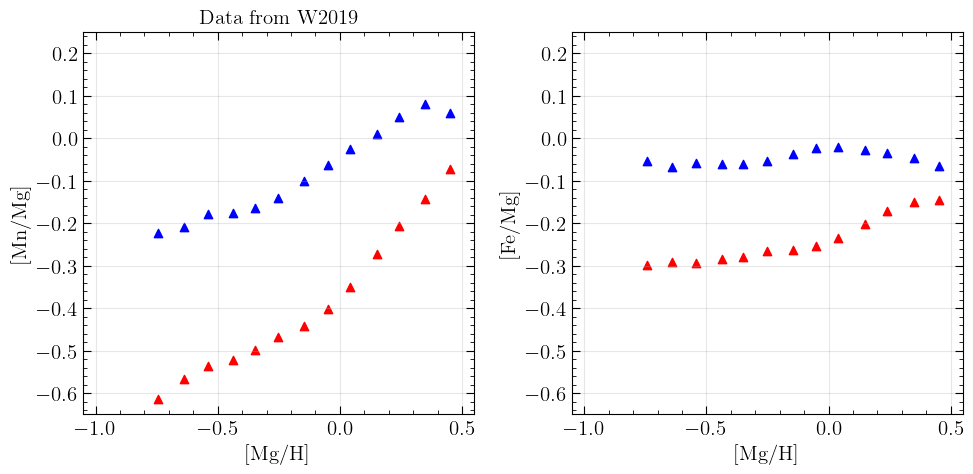

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue')
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('Data from W2019')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')
plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

# First, Constant SFRs

In [4]:
t_array = np.linspace(0.0001,14,int(1e3))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_const = np.ones(len(t_array))

gal_def_2024 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const)
gal_def_2017 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, solarvalues_ref="W2017", yields_ref="W2017")

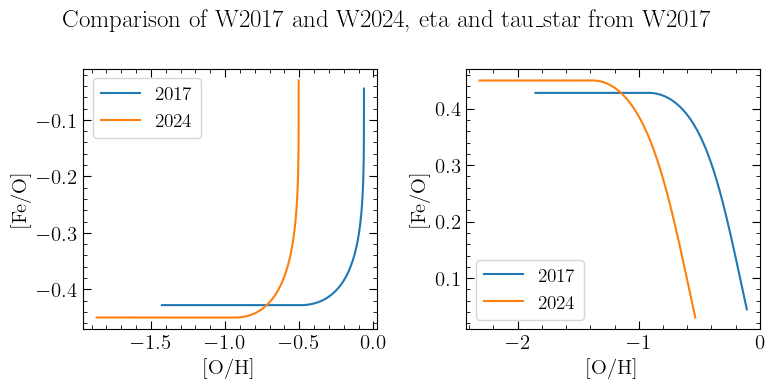

In [5]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(gal_def_2017.O_H[1:], gal_def_2017.Fe_O[1:], label = '2017')
plt.plot(gal_def_2024.O_H[1:], gal_def_2024.Fe_O[1:], label = '2024')

plt.legend()
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O]')

plt.subplot(1,2,2)

plt.plot(gal_def_2017.Fe_H[1:], gal_def_2017.O_Fe[1:], label = '2017')
plt.plot(gal_def_2024.Fe_H[1:], gal_def_2024.O_Fe[1:], label = '2024')

plt.legend()
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O]')

plt.suptitle('Comparison of W2017 and W2024, eta and tau_star from W2017')
plt.tight_layout()

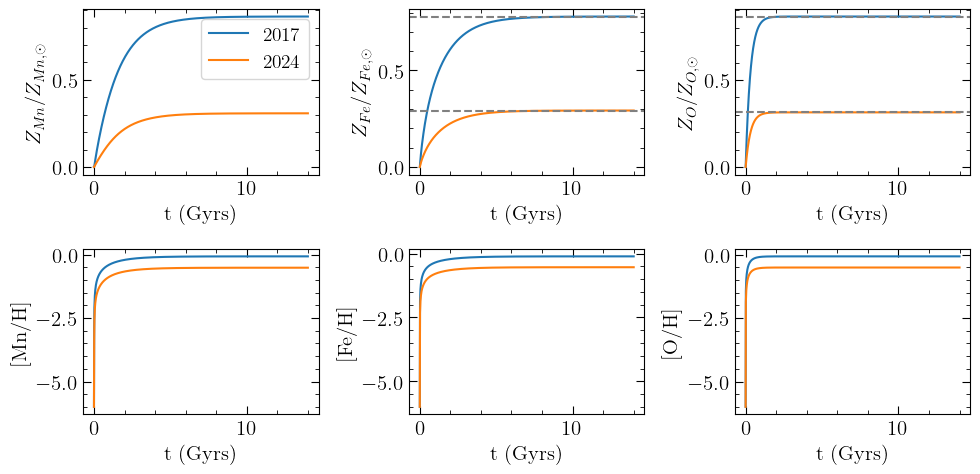

In [6]:
plt.figure(figsize=(10,5))
plt.subplot(2,3,1)
plt.plot(t_array, gal_def_2017.compute_z_X()/gal_def_2017.SolarMn, label = '2017')
plt.plot(t_array, gal_def_2024.compute_z_X()/gal_def_2024.SolarMn, label = '2024')
plt.xlabel('t (Gyrs)')
plt.ylabel(r'$Z_{Mn}/Z_{Mn,\odot}$')
plt.legend()

plt.subplot(2,3,2)
plt.plot(t_array, gal_def_2017.compute_z_Fe()/gal_def_2017.SolarFe, label = '2017')
plt.plot(t_array, gal_def_2024.compute_z_Fe()/gal_def_2024.SolarFe, label = '2024')
plt.axhline(gal_def_2017.analytic_eq_Fe(SFR_function="constant")/gal_def_2017.SolarFe, color = 'gray', linestyle='--')
plt.axhline(gal_def_2024.analytic_eq_Fe(SFR_function="constant")/gal_def_2024.SolarFe, color = 'gray', linestyle='--')
plt.xlabel('t (Gyrs)')
plt.ylabel(r'$Z_{Fe}/Z_{Fe,\odot}$')

plt.subplot(2,3,3)
plt.plot(t_array, gal_def_2017.compute_z_O()/gal_def_2017.SolarO, label = '2017')
plt.plot(t_array, gal_def_2024.compute_z_O()/gal_def_2024.SolarO, label = '2024')
plt.axhline(gal_def_2017.analytic_eq_O(SFR_function="constant")/gal_def_2017.SolarO, color = 'gray', linestyle='--')
plt.axhline(gal_def_2024.analytic_eq_O(SFR_function="constant")/gal_def_2024.SolarO, color = 'gray', linestyle='--')
plt.xlabel('t (Gyrs)')
plt.ylabel(r'$Z_{O}/Z_{O,\odot}$')

plt.subplot(2,3,4)
plt.plot(t_array, gal_def_2017.Mn_H, label = '2017')
plt.plot(t_array, gal_def_2024.Mn_H, label = '2024')
plt.xlabel('t (Gyrs)')
plt.ylabel('[Mn/H]')

plt.subplot(2,3,5)
plt.plot(t_array, gal_def_2017.Fe_H, label = '2017')
plt.plot(t_array, gal_def_2024.Fe_H, label = '2024')
plt.xlabel('t (Gyrs)')
plt.ylabel('[Fe/H]')

plt.subplot(2,3,6)
plt.plot(t_array, gal_def_2017.O_H, label = '2017')
plt.plot(t_array, gal_def_2024.O_H, label = '2024')
plt.xlabel('t (Gyrs)')
plt.ylabel('[O/H]')

plt.tight_layout()

# Now let's change tau_* and eta

In [7]:
print(f"WAF2017: Tau_* = {gal_def_2017.tau_star_arr[0]}, eta = {gal_def_2017.eta_arr[0]}")

WAF2017: Tau_* = 1.0, eta = 2.5


In [8]:
#modified, 2024
gal_mod_2024 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, eta = 0.95, tau_star=1)
gal_mod2_2024 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, eta = 0.95, tau_star=2)

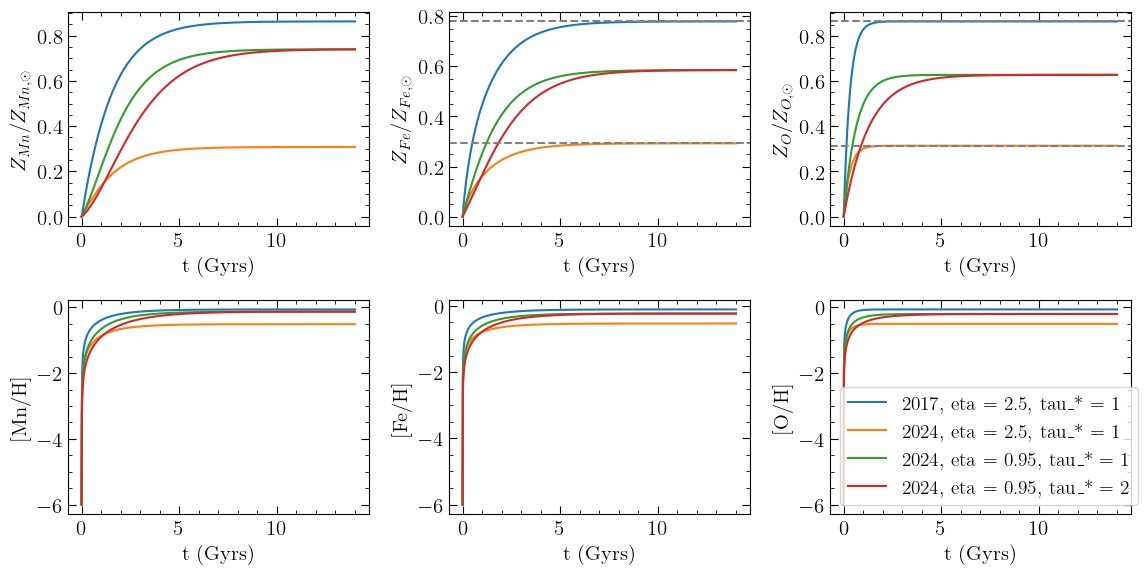

In [9]:
plt.figure(figsize=(12,6))
plt.subplot(2,3,1)
plt.plot(t_array, gal_def_2017.compute_z_X()/gal_def_2017.SolarMn, label = '2017, eta = 2.5, tau_* = 1')
plt.plot(t_array, gal_def_2024.compute_z_X()/gal_def_2024.SolarMn, label = '2024, eta = 2.5, tau_* = 1')
plt.plot(t_array, gal_mod_2024.compute_z_X()/gal_mod_2024.SolarMn, label = '2024, eta = 0.95, tau_* = 1')
plt.plot(t_array, gal_mod2_2024.compute_z_X()/gal_mod2_2024.SolarMn, label = '2024, eta = 0.95, tau_* = 2')
plt.xlabel('t (Gyrs)')
plt.ylabel(r'$Z_{Mn}/Z_{Mn,\odot}$')
#plt.legend()

plt.subplot(2,3,2)
plt.plot(t_array, gal_def_2017.compute_z_Fe()/gal_def_2017.SolarFe, label = '2017')
plt.plot(t_array, gal_def_2024.compute_z_Fe()/gal_def_2024.SolarFe, label = '2024')
plt.plot(t_array, gal_mod_2024.compute_z_Fe()/gal_mod_2024.SolarFe, label = 'mod,2024')
plt.plot(t_array, gal_mod2_2024.compute_z_Fe()/gal_mod2_2024.SolarFe, label = 'mod,2024')
plt.axhline(gal_def_2017.analytic_eq_Fe(SFR_function="constant")/gal_def_2017.SolarFe, color = 'gray', linestyle='--')
plt.axhline(gal_def_2024.analytic_eq_Fe(SFR_function="constant")/gal_def_2024.SolarFe, color = 'gray', linestyle='--')
plt.xlabel('t (Gyrs)')
plt.ylabel(r'$Z_{Fe}/Z_{Fe,\odot}$')

plt.subplot(2,3,3)
plt.plot(t_array, gal_def_2017.compute_z_O()/gal_def_2017.SolarO, label = '2017')
plt.plot(t_array, gal_def_2024.compute_z_O()/gal_def_2024.SolarO, label = '2024')
plt.plot(t_array, gal_mod_2024.compute_z_O()/gal_mod_2024.SolarO, label = 'mod,2024')
plt.plot(t_array, gal_mod2_2024.compute_z_O()/gal_mod2_2024.SolarO, label = 'mod,2024')
plt.axhline(gal_def_2017.analytic_eq_O(SFR_function="constant")/gal_def_2017.SolarO, color = 'gray', linestyle='--')
plt.axhline(gal_def_2024.analytic_eq_O(SFR_function="constant")/gal_def_2024.SolarO, color = 'gray', linestyle='--')
plt.xlabel('t (Gyrs)')
plt.ylabel(r'$Z_{O}/Z_{O,\odot}$')

plt.subplot(2,3,4)
plt.plot(t_array, gal_def_2017.Mn_H, label = '2017')
plt.plot(t_array, gal_def_2024.Mn_H, label = '2024')
plt.plot(t_array, gal_mod_2024.Mn_H, label = 'mod,2024')
plt.plot(t_array, gal_mod2_2024.Mn_H, label = 'mod,2024')
plt.xlabel('t (Gyrs)')
plt.ylabel('[Mn/H]')

plt.subplot(2,3,5)
plt.plot(t_array, gal_def_2017.Fe_H, label = '2017')
plt.plot(t_array, gal_def_2024.Fe_H, label = '2024')
plt.plot(t_array, gal_mod_2024.Fe_H, label = 'mod,2024')
plt.plot(t_array, gal_mod2_2024.Fe_H, label = 'mod,2024')
plt.xlabel('t (Gyrs)')
plt.ylabel('[Fe/H]')

plt.subplot(2,3,6)
plt.plot(t_array, gal_def_2017.O_H, label = '2017, eta = 2.5, tau_* = 1')
plt.plot(t_array, gal_def_2024.O_H, label = '2024, eta = 2.5, tau_* = 1')
plt.plot(t_array, gal_mod_2024.O_H, label = '2024, eta = 0.95, tau_* = 1')
plt.plot(t_array, gal_mod2_2024.O_H, label = '2024, eta = 0.95, tau_* = 2')


plt.legend()
plt.xlabel('t (Gyrs)')
plt.ylabel('[O/H]')

plt.tight_layout()

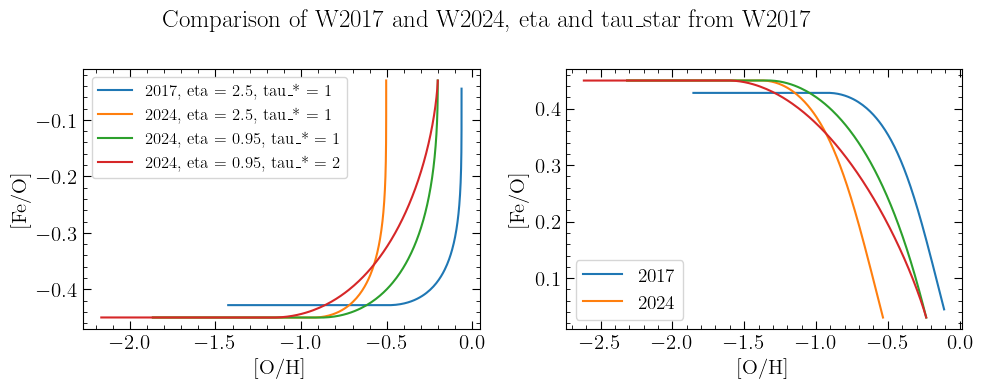

In [10]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(gal_def_2017.O_H[1:], gal_def_2017.Fe_O[1:], label = '2017, eta = 2.5, tau_* = 1')
plt.plot(gal_def_2024.O_H[1:], gal_def_2024.Fe_O[1:], label = '2024, eta = 2.5, tau_* = 1')
plt.plot(gal_mod_2024.O_H[1:], gal_mod_2024.Fe_O[1:], label = '2024, eta = 0.95, tau_* = 1')
plt.plot(gal_mod2_2024.O_H[1:], gal_mod2_2024.Fe_O[1:], label = '2024, eta = 0.95, tau_* = 2')

plt.legend(loc='upper left', fontsize=12)
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O]')

plt.subplot(1,2,2)

plt.plot(gal_def_2017.Fe_H[1:], gal_def_2017.O_Fe[1:], label = '2017')
plt.plot(gal_def_2024.Fe_H[1:], gal_def_2024.O_Fe[1:], label = '2024')
plt.plot(gal_mod_2024.Fe_H[1:], gal_mod_2024.O_Fe[1:])
plt.plot(gal_mod2_2024.Fe_H[1:], gal_mod2_2024.O_Fe[1:])

plt.legend()
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O]')

plt.suptitle('Comparison of W2017 and W2024, eta and tau_star from W2017')
plt.tight_layout()

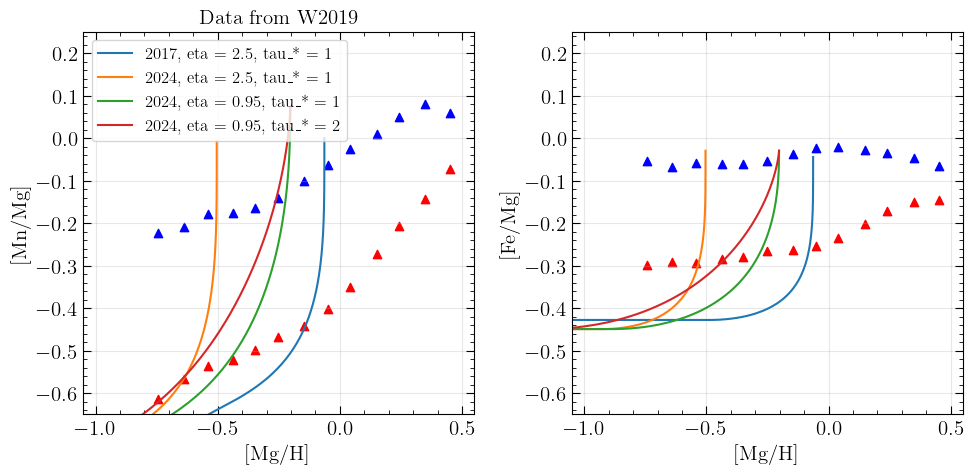

In [11]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue')
plt.plot(gal_def_2017.O_H, gal_def_2017.Mn_O, label = '2017, eta = 2.5, tau_* = 1')
plt.plot(gal_def_2024.Mg_H, gal_def_2024.Mn_Mg, label = '2024, eta = 2.5, tau_* = 1')
plt.plot(gal_mod_2024.Mg_H, gal_mod_2024.Mn_Mg, label = '2024, eta = 0.95, tau_* = 1')
plt.plot(gal_mod2_2024.Mg_H, gal_mod2_2024.Mn_Mg, label = '2024, eta = 0.95, tau_* = 2')
plt.grid('True', alpha = 0.3)
plt.legend(loc = 'upper left', fontsize=12)
plt.ylim(-0.65,0.25)
plt.title('Data from W2019')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')
plt.plot(gal_def_2017.O_H, gal_def_2017.Fe_O)
plt.plot(gal_def_2024.Mg_H, gal_def_2024.Fe_Mg)
plt.plot(gal_mod_2024.Mg_H, gal_mod_2024.Fe_Mg)
plt.plot(gal_mod2_2024.Mg_H, gal_mod2_2024.Fe_Mg)

plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

# Exp SFRs?

In [12]:
gal_exp_2017 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, solarvalues_ref="W2017", yields_ref="W2017")
gal_exp_2024 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp)
gal_exp_low_eta= evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, eta = 0.95, tau_star = 1)
gal_exp_high_taustr = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, eta = 0.95, tau_star=2)

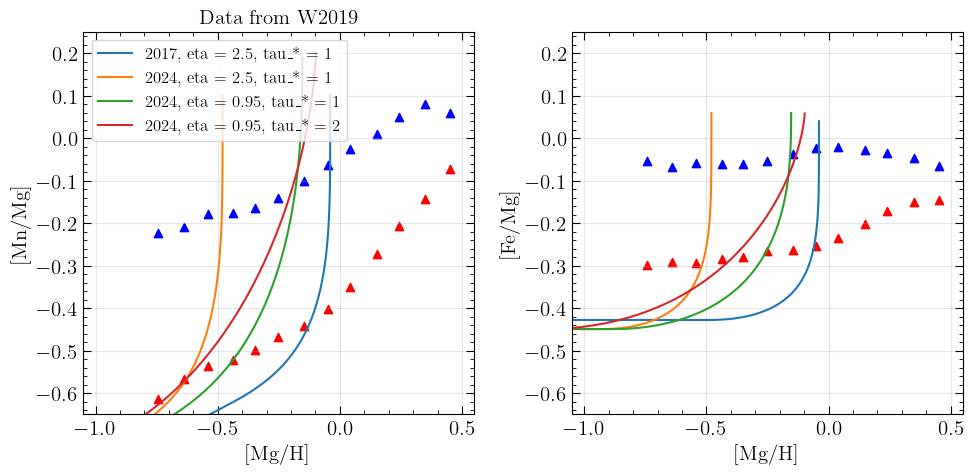

In [13]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue')
plt.plot(gal_exp_2017.O_H, gal_exp_2017.Mn_O, label = '2017, eta = 2.5, tau_* = 1')
plt.plot(gal_exp_2024.Mg_H, gal_exp_2024.Mn_Mg, label = '2024, eta = 2.5, tau_* = 1')
plt.plot(gal_exp_low_eta.Mg_H, gal_exp_low_eta.Mn_Mg, label = '2024, eta = 0.95, tau_* = 1')
plt.plot(gal_exp_high_taustr.Mg_H, gal_exp_high_taustr.Mn_Mg, label = '2024, eta = 0.95, tau_* = 2')
plt.grid('True', alpha = 0.3)
plt.legend(loc = 'upper left', fontsize=12)
plt.ylim(-0.65,0.25)
plt.title('Data from W2019')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')
plt.plot(gal_exp_2017.O_H, gal_exp_2017.Fe_O, label = '2017, eta = 2.5, tau_* = 1')
plt.plot(gal_exp_2024.Mg_H, gal_exp_2024.Fe_Mg, label = '2024, eta = 2.5, tau_* = 1')
plt.plot(gal_exp_low_eta.Mg_H, gal_exp_low_eta.Fe_Mg, label = '2024, eta = 0.95, tau_* = 1')
plt.plot(gal_exp_high_taustr.Mg_H, gal_exp_high_taustr.Fe_Mg, label = '2024, eta = 0.95, tau_* = 2')

plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

(-1.05, 0.55)

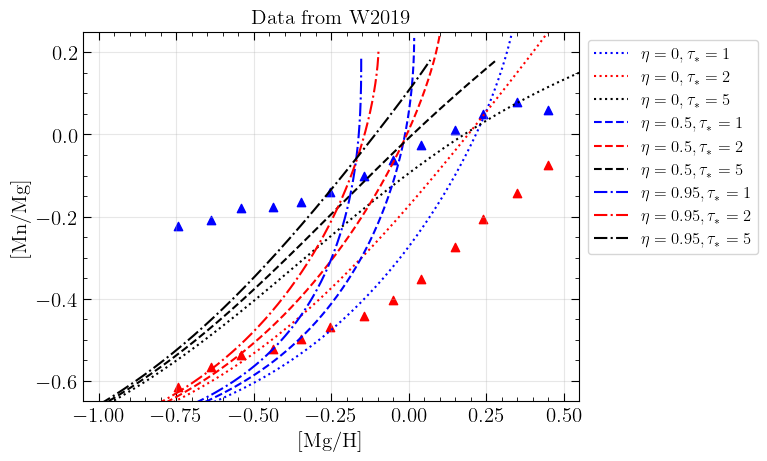

In [14]:
etas = [0, 0.5, 0.95]
tau_stars = [1, 2, 5]
#tau_sfhs = [3, 6, 10]
#tau_Ias = [0.5, 1.5, 3]
tau_sfhs = [6]
tau_Ias = [1.5]
linestyles = [':', '--', '-.']
colors = ['blue', 'red', 'black', 'green', 'magenta']

for i, eta in enumerate(etas):
    lstyle = linestyles[i % len(linestyles)]
    for j, taustar in enumerate(tau_stars):
        clr = colors[j % len(colors)]
        for tau_sfh in tau_sfhs:
            for tau_Ia in tau_Ias:
                gal_temp = evo.Galaxy(t_array=t_array, m_g_array=1 * np.exp(-t_array/tau_sfh), eta = eta, tau_star=taustar,
                                      tau_sfh=tau_sfh, tau_Ia=tau_Ia)
                #label = rf"$\eta = {eta}, \tau_* = {taustar}, \tau_s = {tau_sfh}, \tau_Ia = {tau_Ia}$"
                label = rf"$\eta = {eta}, \tau_* = {taustar}$"
                plt.plot(gal_temp.Mg_H[1:], gal_temp.Mn_Mg[1:], label = label, linestyle=lstyle, color=clr)


plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue')
plt.grid('True', alpha = 0.3)
plt.legend(loc = 'upper left', bbox_to_anchor = [1,1],fontsize=12)
plt.ylim(-0.65,0.25)
plt.title('Data from W2019')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)

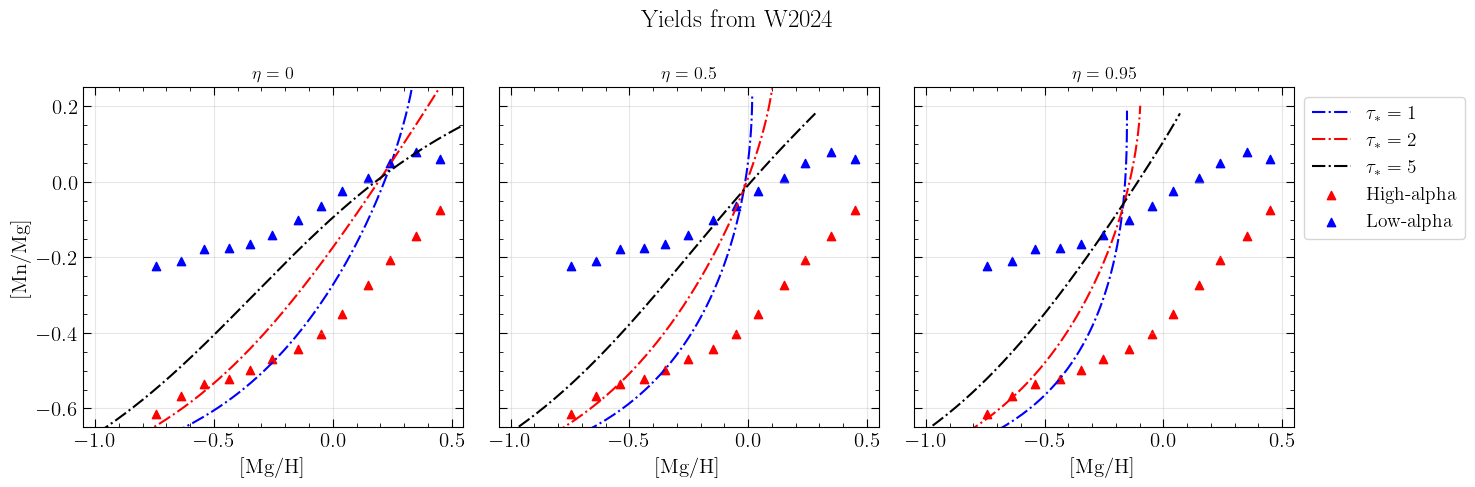

In [15]:
etas = [0, 0.5, 0.95]
tau_stars = [1, 2, 5]
#tau_sfhs = [3, 6, 10]
#tau_Ias = [0.5, 1.5, 3]
tau_sfhs = [6]
tau_Ias = [1.5]
linestyles = ['-']
colors = ['blue', 'red', 'black', 'green', 'magenta']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, eta in enumerate(etas):
    ax = axes[i]
    for j, taustar in enumerate(tau_stars):
        clr = colors[j]
        for tau_sfh in tau_sfhs:
            for tau_Ia in tau_Ias:
                gal_temp = evo.Galaxy(
                    t_array=t_array,
                    m_g_array=1 * np.exp(-t_array/tau_sfh),
                    eta=eta,
                    tau_star=taustar,
                    tau_sfh=tau_sfh,
                    tau_Ia=tau_Ia
                )
                label = rf"$\tau_* = {taustar}$"
                ax.plot(
                    gal_temp.Mg_H[1:], gal_temp.Mn_Mg[1:], 
                    label=label, color=clr, linestyle=lstyle
                )

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)


plt.suptitle("Yields from W2024")
plt.tight_layout()
plt.show()


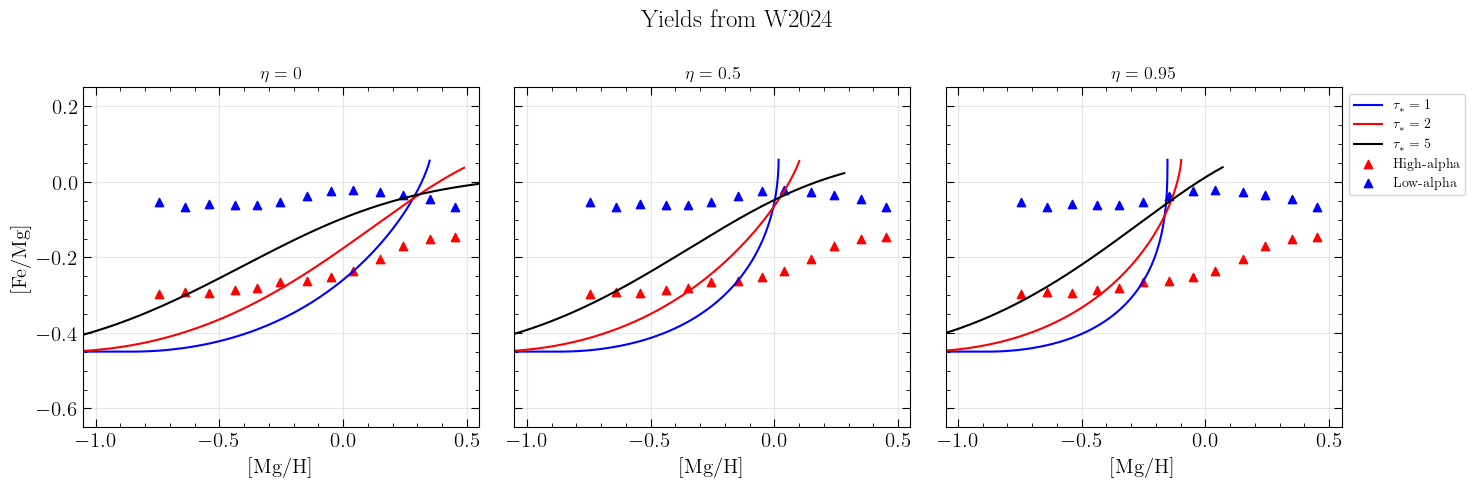

In [16]:
etas = [0, 0.5, 0.95]
tau_stars = [1, 2, 5]
#tau_sfhs = [3, 6, 10]
#tau_Ias = [0.5, 1.5, 3]
tau_sfhs = [6]
tau_Ias = [1.5]
linestyles = ['-']
colors = ['blue', 'red', 'black', 'green', 'magenta']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, eta in enumerate(etas):
    ax = axes[i]
    for j, taustar in enumerate(tau_stars):
        clr = colors[j % len(colors)]
        lstyle = linestyles[j % len(linestyles)]
        for tau_sfh in tau_sfhs:
            for tau_Ia in tau_Ias:
                gal_temp = evo.Galaxy(
                    t_array=t_array,
                    m_g_array=1 * np.exp(-t_array/tau_sfh),
                    eta=eta,
                    tau_star=taustar,
                    tau_sfh=tau_sfh,
                    tau_Ia=tau_Ia
                )
                label = rf"$\tau_* = {taustar}$"
                ax.plot(
                    gal_temp.Mg_H[1:], gal_temp.Fe_Mg[1:], 
                    label=label, color=clr, linestyle=lstyle
                )

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H]')
    if i == 0:
        ax.set_ylabel('[Fe/Mg]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)


plt.suptitle("Yields from W2024")
plt.tight_layout()
plt.show()


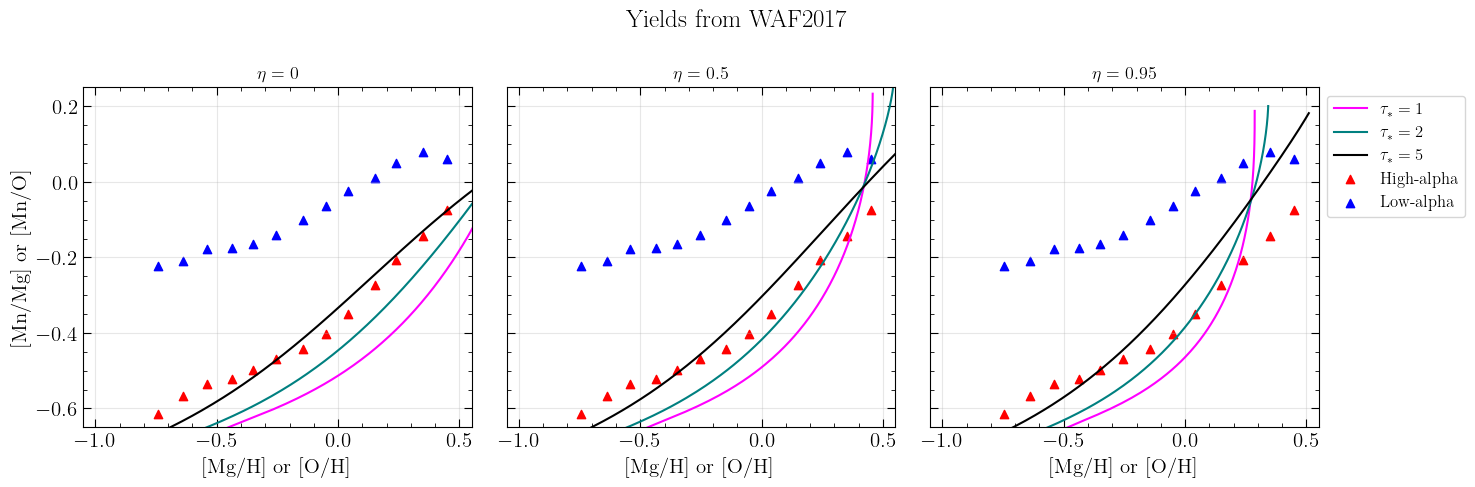

In [17]:
etas = [0, 0.5, 0.95]
tau_stars = [1, 2, 5]
#tau_sfhs = [3, 6, 10]
#tau_Ias = [0.5, 1.5, 3]
tau_sfh = 6
tau_Ia = 1.5
linestyles = ['-']
colors = ['magenta', 'teal', 'black', 'green', 'orange']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, eta in enumerate(etas):
    ax = axes[i]
    for j, taustar in enumerate(tau_stars):
        clr = colors[j % len(colors)]
        gal_temp = evo.Galaxy(
                    t_array=t_array,
                    m_g_array=1 * np.exp(-t_array/tau_sfh),
                    eta=eta,
                    tau_star=taustar,
                    tau_sfh=tau_sfh,
                    tau_Ia=tau_Ia,
                    solarvalues_ref="W2017",
                    yields_ref="W2017"
                )
        label = rf"$\tau_* = {taustar}$"
        ax.plot(gal_temp.O_H[1:], gal_temp.Mn_O[1:], 
                label=label, color=clr, linestyle=lstyle)

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H] or [O/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg] or [Mn/O]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)


plt.suptitle("Yields from WAF2017")
plt.tight_layout()
plt.show()


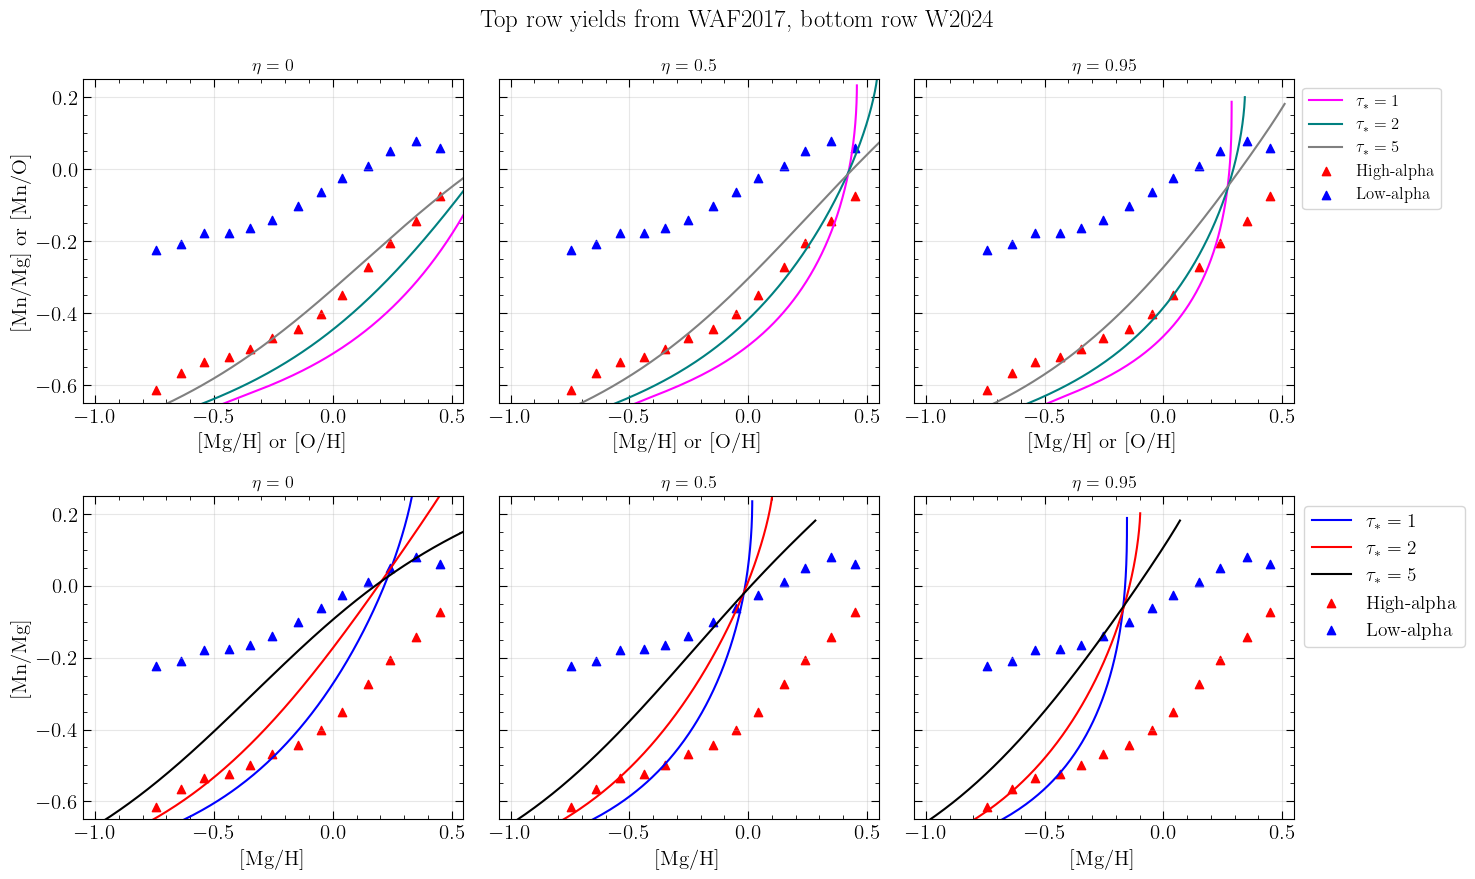

In [18]:
etas = [0, 0.5, 0.95]
tau_stars = [1, 2, 5]
tau_sfh = 6
tau_Ia = 1.5
linestyles = ['-']
colors_2017 = ['magenta', 'teal', 'gray', 'green', 'orange']
colors_2024 = ['blue', 'red', 'black']

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

for i, eta in enumerate(etas):
    ax = axes[0][i]
    for j, taustar in enumerate(tau_stars):
        clr = colors_2017[j]
        gal_temp = evo.Galaxy(
                    t_array=t_array,
                    m_g_array=1 * np.exp(-t_array/tau_sfh),
                    eta=eta,
                    tau_star=taustar,
                    tau_sfh=tau_sfh,
                    tau_Ia=tau_Ia,
                    solarvalues_ref="W2017",
                    yields_ref="W2017"
                )
        label = rf"$\tau_* = {taustar}$"
        ax.plot(gal_temp.O_H[1:], gal_temp.Mn_O[1:], 
                label=label, color=clr, linestyle=lstyle)

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H] or [O/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg] or [Mn/O]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
        



for i, eta in enumerate(etas):
    ax = axes[1][i]
    for j, taustar in enumerate(tau_stars):
        clr = colors_2024[j]
        for tau_sfh in tau_sfhs:
            for tau_Ia in tau_Ias:
                gal_temp = evo.Galaxy(
                    t_array=t_array,
                    m_g_array=1 * np.exp(-t_array/tau_sfh),
                    eta=eta,
                    tau_star=taustar,
                    tau_sfh=tau_sfh,
                    tau_Ia=tau_Ia,
                    solarvalues_ref="W2024",
                    yields_ref="W2024"
                )
                label = rf"$\tau_* = {taustar}$"
                ax.plot(
                    gal_temp.Mg_H[1:], gal_temp.Mn_Mg[1:], 
                    label=label, color=clr, linestyle=lstyle
                )

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)


plt.suptitle("Top row yields from WAF2017, bottom row W2024")
plt.tight_layout()
plt.show()


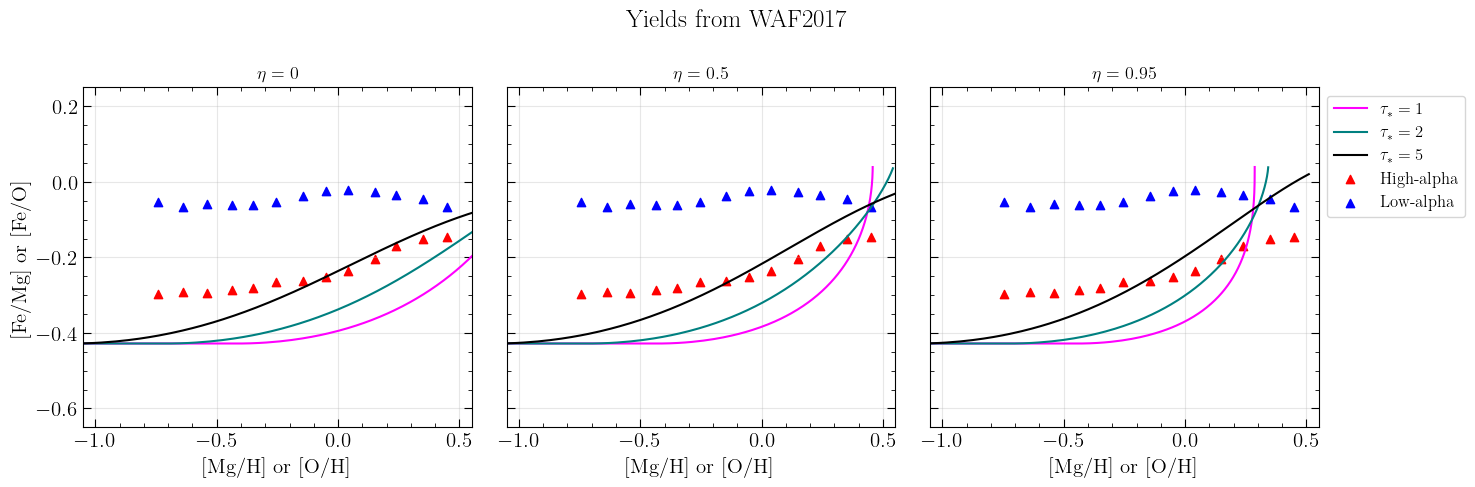

In [19]:
etas = [0, 0.5, 0.95]
tau_stars = [1, 2, 5]
#tau_sfhs = [3, 6, 10]
#tau_Ias = [0.5, 1.5, 3]
tau_sfh = 6
tau_Ia = 1.5
linestyles = ['-']
colors = ['magenta', 'teal', 'black', 'green', 'orange']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, eta in enumerate(etas):
    ax = axes[i]
    for j, taustar in enumerate(tau_stars):
        clr = colors[j % len(colors)]
        gal_temp = evo.Galaxy(
                    t_array=t_array,
                    m_g_array=1 * np.exp(-t_array/tau_sfh),
                    eta=eta,
                    tau_star=taustar,
                    tau_sfh=tau_sfh,
                    tau_Ia=tau_Ia,
                    solarvalues_ref="W2017",
                    yields_ref="W2017"
                )
        label = rf"$\tau_* = {taustar}$"
        ax.plot(gal_temp.O_H[1:], gal_temp.Fe_O[1:], 
                label=label, color=clr, linestyle=lstyle)

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H] or [O/H]')
    if i == 0:
        ax.set_ylabel('[Fe/Mg] or [Fe/O]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)


plt.suptitle("Yields from WAF2017")
plt.tight_layout()
plt.show()


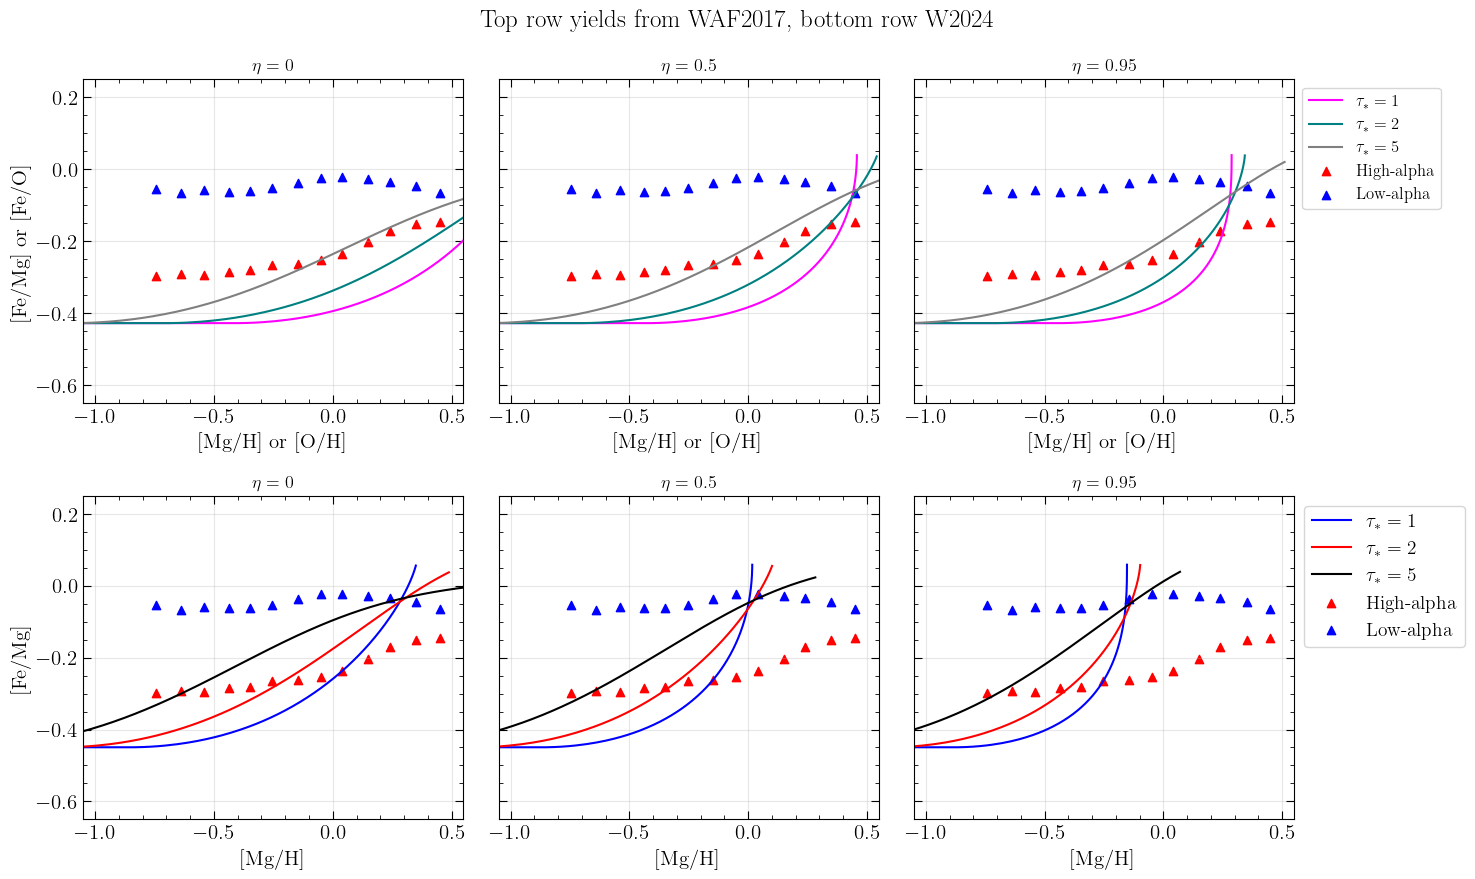

In [20]:
etas = [0, 0.5, 0.95]
tau_stars = [1, 2, 5]
tau_sfh = 6
tau_Ia = 1.5
linestyles = ['-']
colors_2017 = ['magenta', 'teal', 'gray', 'green', 'orange']
colors_2024 = ['blue', 'red', 'black']

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

for i, eta in enumerate(etas):
    ax = axes[0][i]
    for j, taustar in enumerate(tau_stars):
        clr = colors_2017[j]
        gal_temp = evo.Galaxy(
                    t_array=t_array,
                    m_g_array=1 * np.exp(-t_array/tau_sfh),
                    eta=eta,
                    tau_star=taustar,
                    tau_sfh=tau_sfh,
                    tau_Ia=tau_Ia,
                    solarvalues_ref="W2017",
                    yields_ref="W2017"
                )
        label = rf"$\tau_* = {taustar}$"
        ax.plot(gal_temp.O_H[1:], gal_temp.Fe_O[1:], 
                label=label, color=clr, linestyle=lstyle)

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H] or [O/H]')
    if i == 0:
        ax.set_ylabel('[Fe/Mg] or [Fe/O]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)
        



for i, eta in enumerate(etas):
    ax = axes[1][i]
    for j, taustar in enumerate(tau_stars):
        clr = colors_2024[j]
        for tau_sfh in tau_sfhs:
            for tau_Ia in tau_Ias:
                gal_temp = evo.Galaxy(
                    t_array=t_array,
                    m_g_array=1 * np.exp(-t_array/tau_sfh),
                    eta=eta,
                    tau_star=taustar,
                    tau_sfh=tau_sfh,
                    tau_Ia=tau_Ia,
                    solarvalues_ref="W2024",
                    yields_ref="W2024"
                )
                label = rf"$\tau_* = {taustar}$"
                ax.plot(
                    gal_temp.Mg_H[1:], gal_temp.Fe_Mg[1:], 
                    label=label, color=clr, linestyle=lstyle
                )

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H]')
    if i == 0:
        ax.set_ylabel('[Fe/Mg]')
    if i == 2:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=14)


plt.suptitle("Top row yields from WAF2017, bottom row W2024")
plt.tight_layout()
plt.show()


# Let's try eta and tau_* from Figure 8 in W2024 paper

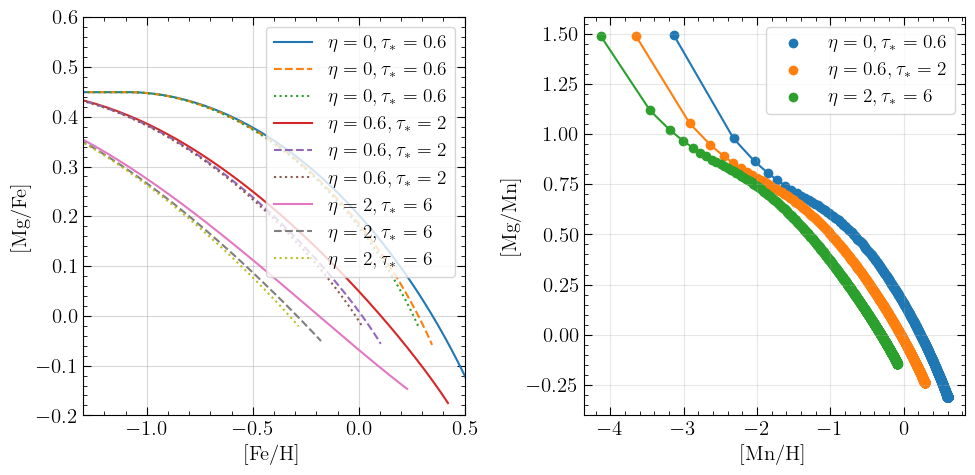

In [21]:
plt.figure(figsize=(10,5))

taustars_fig8 = [0.6, 2, 6]
etas_fig8 = [0, 0.6, 2]
tau_sfh = 6
tau_Ia = 1.5
linestyles = ['-']
colors = ['magenta', 'teal', 'orange', 'dark green']

tau_sfh_vars = [3, 6, 9] #Gyrs
linestyles = ['-', '--', ':']

plt.subplot(1,2,1)
for i in range(len(taustars_fig8)):
    for j in range(len(tau_sfh_vars)):
        taustar=taustars_fig8[i]
        eta=etas_fig8[i]
        label = rf"$\eta = {eta}, \tau_* = {taustar}$"
        m_g_array_exp_var = 1 * np.exp(-t_array/tau_sfh_vars[j])
        gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp_var, eta=eta, tau_star=taustar)
        gal_temp_powerlaw = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp_var, eta=eta, tau_star=taustar, DTD_func="power-law")
        plt.plot(gal_temp.Fe_H[1:], gal_temp.Mg_Fe[1:], label = label, linestyle=linestyles[j])
        #plt.plot(gal_temp_powerlaw.Fe_H[1:], gal_temp_powerlaw.Mg_Fe[1:], label = label, linestyle='--')

plt.grid('True', alpha = 0.5)
plt.legend()
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.xlim(-1.3, 0.5)
plt.ylim(-0.2, 0.6)


plt.subplot(1,2,2)
for i in range(len(taustars_fig8)):
    taustar=taustars_fig8[i]
    eta=etas_fig8[i]
    label = rf"$\eta = {eta}, \tau_* = {taustar}$"
    gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, eta=eta, tau_star=taustar)
    gal_temp_powerlaw = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, eta=eta, tau_star=taustar, DTD_func="power-law")
    plt.scatter(gal_temp.Mn_H[1:], gal_temp.Mg_Mn[1:], label = label, linestyle = '-')
    plt.plot(gal_temp.Mn_H[1:], gal_temp.Mg_Mn[1:], linestyle = '-')
    #plt.plot(gal_temp_powerlaw.Mn_H[1:], gal_temp_powerlaw.Mg_Mn[1:], label = label, linestyle = '--')

plt.grid('True', alpha = 0.3)
plt.legend()
plt.xlabel('[Mn/H]')
plt.ylabel('[Mg/Mn]')

plt.tight_layout()

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_37346/775981400.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


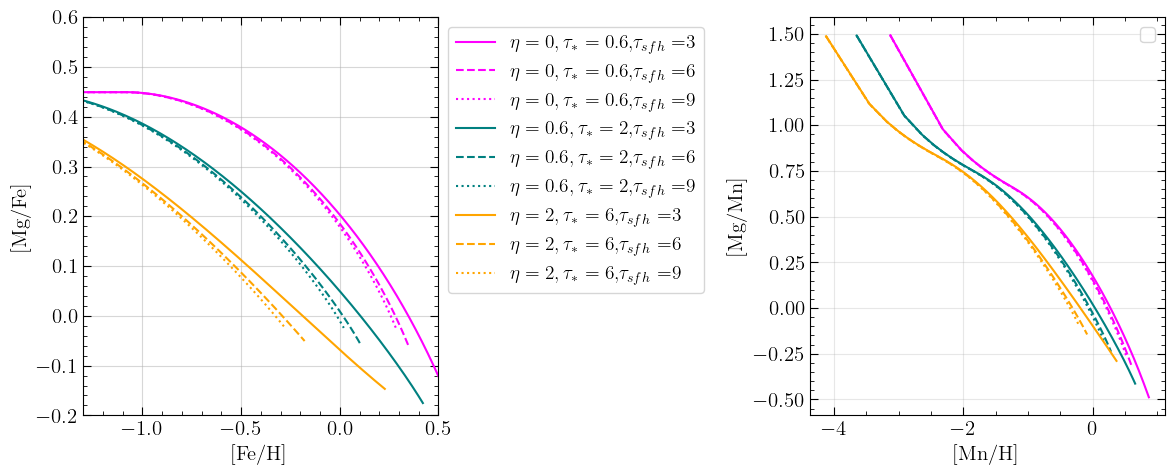

In [22]:
plt.figure(figsize=(12,5))

taustars_fig8 = [0.6, 2, 6]
etas_fig8 = [0, 0.6, 2]
tau_sfh = 6
tau_Ia = 1.5
linestyles = ['-']
colors = ['magenta', 'teal', 'orange', 'dark green']

tau_sfh_vars = [3, 6, 9] #Gyrs
linestyles = ['-', '--', ':']

plt.subplot(1,2,1)
for i in range(len(taustars_fig8)):
    for j in range(len(tau_sfh_vars)):
        taustar=taustars_fig8[i]
        eta=etas_fig8[i]
        label = rf"$\eta = {eta}, \tau_* = {taustar}, $" + r"$\tau_{sfh} = $"+f"{tau_sfh_vars[j]}"
        m_g_array_exp_var = 1 * np.exp(-t_array/tau_sfh_vars[j])
        gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp_var, eta=eta, tau_star=taustar)
        #gal_temp_powerlaw = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp_var, eta=eta, tau_star=taustar, DTD_func="power-law")
        plt.plot(gal_temp.Fe_H[1:], gal_temp.Mg_Fe[1:], label = label, linestyle=linestyles[j], color = colors[i])
        #plt.plot(gal_temp_powerlaw.Fe_H[1:], gal_temp_powerlaw.Mg_Fe[1:], label = label, linestyle='--')

plt.grid('True', alpha = 0.5)
plt.legend(loc='upper left', bbox_to_anchor=[1,1])
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.xlim(-1.3, 0.5)
plt.ylim(-0.2, 0.6)


plt.subplot(1,2,2)
for i in range(len(taustars_fig8)):
    for j in range(len(tau_sfh_vars)):
        taustar=taustars_fig8[i]
        eta=etas_fig8[i]
        label = rf"$\eta = {eta}, \tau_* = {taustar}$"
        m_g_array_exp_var = 1 * np.exp(-t_array/tau_sfh_vars[j])
        gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp_var, eta=eta, tau_star=taustar)
        #gal_temp_powerlaw = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, eta=eta, tau_star=taustar, DTD_func="power-law")
        #plt.scatter(gal_temp.Mn_H[1:], gal_temp.Mg_Mn[1:], label = label, linestyle = '-', color = colors[i])
        plt.plot(gal_temp.Mn_H[1:], gal_temp.Mg_Mn[1:], color = colors[i], linestyle=linestyles[j])
        #plt.plot(gal_temp_powerlaw.Mn_H[1:], gal_temp_powerlaw.Mg_Mn[1:], label = label, linestyle = '--')

plt.grid('True', alpha = 0.3)
plt.legend()
plt.xlabel('[Mn/H]')
plt.ylabel('[Mg/Mn]')

plt.tight_layout()

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_37346/2949617691.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


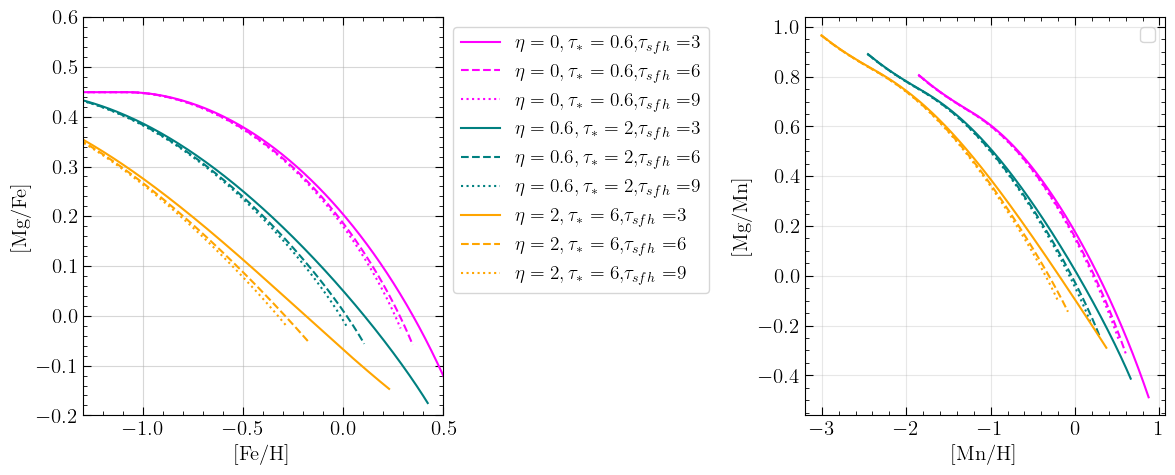

In [43]:
plt.figure(figsize=(12,5))

taustars_fig8 = [0.6, 2, 6]
etas_fig8 = [0, 0.6, 2]
tau_sfh = 6
tau_Ia = 1.5
linestyles = ['-']
colors = ['magenta', 'teal', 'orange', 'dark green']

tau_sfh_vars = [3, 6, 9] #Gyrs
tau_sfhs_2017 = [4, 6, 30]
linestyles = ['-', '--', ':']

plt.subplot(1,2,1)
for i in range(len(taustars_fig8)):
    for j in range(len(tau_sfh_vars)):
        taustar=taustars_fig8[i]
        eta=etas_fig8[i]
        label = rf"$\eta = {eta}, \tau_* = {taustar}, $" + r"$\tau_{sfh} = $"+f"{tau_sfh_vars[j]}"
        m_g_array_exp_var = 1 * np.exp(-t_array/tau_sfh_vars[j])
        gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp_var, eta=eta, tau_star=taustar)
        #gal_temp_powerlaw = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp_var, eta=eta, tau_star=taustar, DTD_func="power-law")
        plt.plot(gal_temp.Fe_H[1:], gal_temp.Mg_Fe[1:], label = label, linestyle=linestyles[j], color = colors[i])
        #plt.plot(gal_temp_powerlaw.Fe_H[1:], gal_temp_powerlaw.Mg_Fe[1:], label = label, linestyle='--')

plt.grid('True', alpha = 0.5)
plt.legend(loc='upper left', bbox_to_anchor=[1,1])
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.xlim(-1.3, 0.5)
plt.ylim(-0.2, 0.6)


plt.subplot(1,2,2)
for i in range(len(taustars_fig8)):
    for j in range(len(tau_sfh_vars)):
        taustar=taustars_fig8[i]
        eta=etas_fig8[i]
        label = rf"$\eta = {eta}, \tau_* = {taustar}$"
        m_g_array_exp_var = 1 * np.exp(-t_array/tau_sfh_vars[j])
        gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp_var, eta=eta, tau_star=taustar)
        #gal_temp_powerlaw = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, eta=eta, tau_star=taustar, DTD_func="power-law")
        #plt.scatter(gal_temp.Mn_H[1:], gal_temp.Mg_Mn[1:], label = label, linestyle = '-', color = colors[i])
        plt.plot(gal_temp.Mn_H[4:], gal_temp.Mg_Mn[4:], color = colors[i], linestyle=linestyles[j])
        #plt.plot(gal_temp_powerlaw.Mn_H[1:], gal_temp_powerlaw.Mg_Mn[1:], label = label, linestyle = '--')

plt.grid('True', alpha = 0.3)
plt.legend()
plt.xlabel('[Mn/H]')
plt.ylabel('[Mg/Mn]')

plt.tight_layout()

/Users/honeyeah/Codes/chemevo/chemevo/evolution.py:170: RuntimeWarning: invalid value encountered in divide
  z_O = m_O / self.m_g_array
/Users/honeyeah/Codes/chemevo/chemevo/evolution.py:193: RuntimeWarning: invalid value encountered in divide
  z_Mg = m_Mg / self.m_g_array
/Users/honeyeah/Codes/chemevo/chemevo/evolution.py:260: RuntimeWarning: invalid value encountered in divide
  z_Fe = m_Fe/self.m_g_array
/Users/honeyeah/Codes/chemevo/chemevo/evolution.py:315: RuntimeWarning: invalid value encountered in divide
  self.Z_X_from_cc = mass_X_from_cc/self.m_g_array
/Users/honeyeah/Codes/chemevo/chemevo/evolution.py:316: RuntimeWarning: invalid value encountered in divide
  self.Z_X_from_Ia = mass_X_from_Ia/self.m_g_array
/Users/honeyeah/Codes/chemevo/chemevo/evolution.py:317: RuntimeWarning: invalid value encountered in divide
  z_X = m_X/self.m_g_array


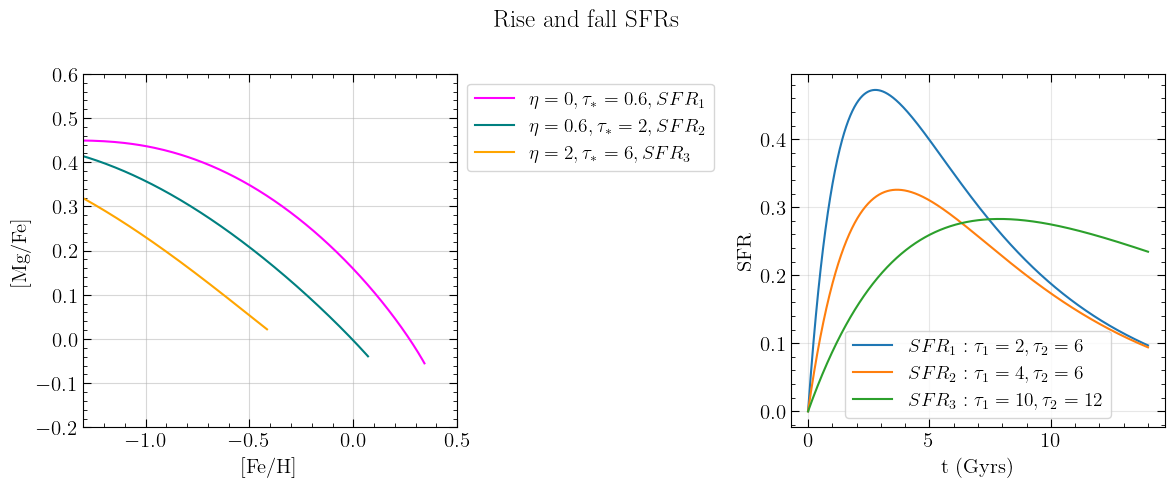

In [57]:
plt.figure(figsize=(12,5))

def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

tau_1s = [2, 4, 10]
tau_2s = [6, 6, 12]
sfr_1 = rise_fall(t_array, tau_1s[0], tau_2s[0])
sfr_2 = rise_fall(t_array, tau_1s[1], tau_2s[1])
sfr_3 = rise_fall(t_array, tau_1s[2], tau_2s[2])
sfrs = [sfr_1, sfr_2, sfr_3]


taustars_fig8 = [0.6, 2, 6]
etas_fig8 = [0, 0.6, 2]
tau_sfh = 6
tau_Ia = 1.5
linestyles = ['-']
colors = ['magenta', 'teal', 'orange', 'dark green']

tau_sfh_vars = [3, 6, 9] #Gyrs
tau_sfhs_2017 = [4, 6, 30]
linestyles = ['-', '--', ':']



plt.subplot(1,2,1)
for i in range(len(taustars_fig8)):
    taustar=taustars_fig8[i]
    eta=etas_fig8[i]
    label = rf"$\eta = {eta}, \tau_* = {taustar}, SFR_{i+1}$"
    sfr = sfrs[i]
    gal_temp = evo.Galaxy(t_array=t_array, m_g_array=sfr, eta=eta, tau_star=taustar)
    #gal_temp_powerlaw = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp_var, eta=eta, tau_star=taustar, DTD_func="power-law")
    plt.plot(gal_temp.Fe_H[1:], gal_temp.Mg_Fe[1:], label = label, linestyle='-', color = colors[i])
    #plt.plot(gal_temp_powerlaw.Fe_H[1:], gal_temp_powerlaw.Mg_Fe[1:], label = label, linestyle='--')

plt.grid('True', alpha = 0.5)
plt.legend(loc='upper left', bbox_to_anchor=[1,1])
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.xlim(-1.3, 0.5)
plt.ylim(-0.2, 0.6)


plt.subplot(1,2,2)
plt.plot(t_array, sfr_1, label = rf'$SFR_1 : \tau_1 = {tau_1s[0]}, \tau_2 = {tau_2s[0]}$')
plt.plot(t_array, sfr_2, label = rf'$SFR_2 : \tau_1 = {tau_1s[1]}, \tau_2 = {tau_2s[1]}$')
plt.plot(t_array, sfr_3, label = rf'$SFR_3 : \tau_1 = {tau_1s[2]}, \tau_2 = {tau_2s[2]}$')

plt.grid('True', alpha = 0.3)
plt.legend()
plt.xlabel('t (Gyrs)')
plt.ylabel('SFR')

plt.suptitle("Rise and fall SFRs")
plt.tight_layout()

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_37346/2601639149.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


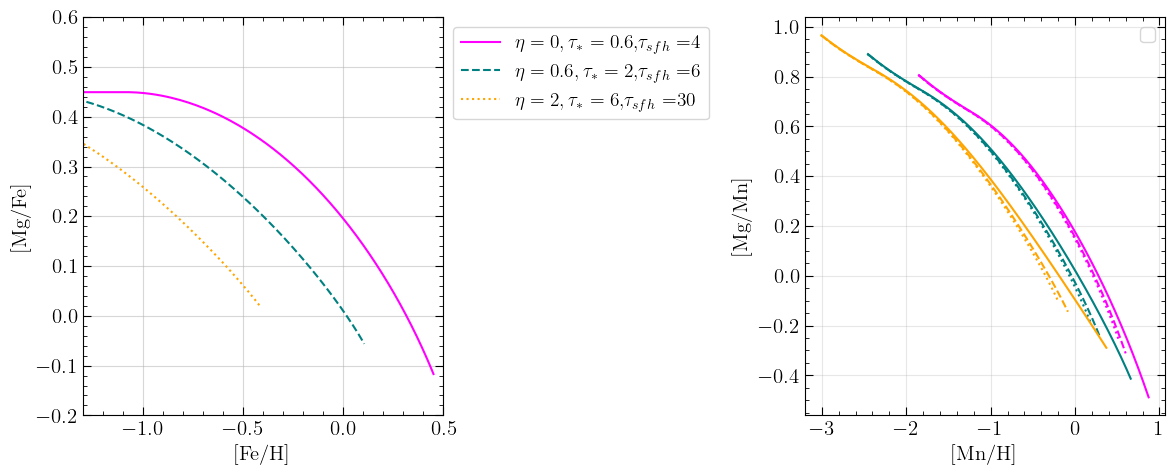

In [42]:
plt.figure(figsize=(12,5))

taustars_fig8 = [0.6, 2, 6]
etas_fig8 = [0, 0.6, 2]
tau_sfh = 6
tau_Ia = 1.5
linestyles = ['-']
colors = ['magenta', 'teal', 'orange', 'dark green']

tau_sfh_vars = [3, 6, 9] #Gyrs
tau_sfhs_2017 = [4, 6, 30]
linestyles = ['-', '--', ':']

plt.subplot(1,2,1)
for i in range(len(taustars_fig8)):
        taustar=taustars_fig8[i]
        eta=etas_fig8[i]
        label = rf"$\eta = {eta}, \tau_* = {taustar}, $" + r"$\tau_{sfh} = $"+f"{tau_sfhs_2017[i]}"
        m_g_array_exp_var = 1 * np.exp(-t_array/tau_sfhs_2017[i])
        gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp_var, eta=eta, tau_star=taustar)
        #gal_temp_powerlaw = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp_var, eta=eta, tau_star=taustar, DTD_func="power-law")
        plt.plot(gal_temp.Fe_H[1:], gal_temp.Mg_Fe[1:], label = label, linestyle=linestyles[i], color = colors[i])
        #plt.plot(gal_temp_powerlaw.Fe_H[1:], gal_temp_powerlaw.Mg_Fe[1:], label = label, linestyle='--')

plt.grid('True', alpha = 0.5)
plt.legend(loc='upper left', bbox_to_anchor=[1,1])
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.xlim(-1.3, 0.5)
plt.ylim(-0.2, 0.6)


plt.subplot(1,2,2)
for i in range(len(taustars_fig8)):
    for j in range(len(tau_sfh_vars)):
        taustar=taustars_fig8[i]
        eta=etas_fig8[i]
        label = rf"$\eta = {eta}, \tau_* = {taustar}$"
        m_g_array_exp_var = 1 * np.exp(-t_array/tau_sfh_vars[j])
        gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp_var, eta=eta, tau_star=taustar)
        #gal_temp_powerlaw = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, eta=eta, tau_star=taustar, DTD_func="power-law")
        #plt.scatter(gal_temp.Mn_H[1:], gal_temp.Mg_Mn[1:], label = label, linestyle = '-', color = colors[i])
        plt.plot(gal_temp.Mn_H[4:], gal_temp.Mg_Mn[4:], color = colors[i], linestyle=linestyles[j])
        #plt.plot(gal_temp_powerlaw.Mn_H[1:], gal_temp_powerlaw.Mg_Mn[1:], label = label, linestyle = '--')

plt.grid('True', alpha = 0.3)
plt.legend()
plt.xlabel('[Mn/H]')
plt.ylabel('[Mg/Mn]')

plt.tight_layout()

In [24]:
highalpha['[Fe/H]'] = highalpha['[Fe/Mg]'] + highalpha['[Mg/H]']
highalpha['[Mn/H]'] = highalpha['[Mn/Mg]'] + highalpha['[Mg/H]']
highalpha['[Mg/Fe]'] = highalpha['[Mg/H]'] - highalpha['[Fe/H]']
highalpha['[Mg/Mn]'] = highalpha['[Mg/H]'] - highalpha['[Mn/H]']

lowalpha['[Fe/H]'] = lowalpha['[Fe/Mg]'] + lowalpha['[Mg/H]']
lowalpha['[Mn/H]'] = lowalpha['[Mn/Mg]'] + lowalpha['[Mg/H]']
lowalpha['[Mg/Fe]'] = lowalpha['[Mg/H]'] - lowalpha['[Fe/H]']
lowalpha['[Mg/Mn]'] = lowalpha['[Mg/H]'] - lowalpha['[Mn/H]']

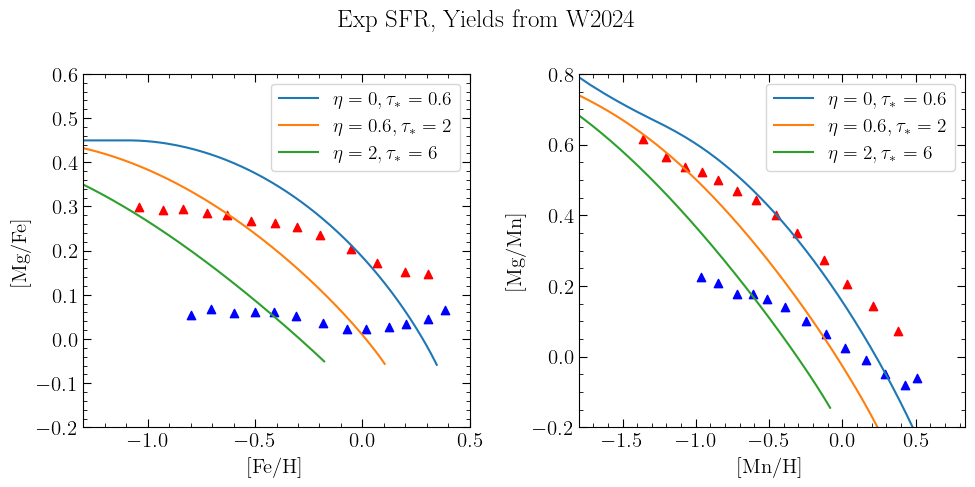

In [25]:
plt.figure(figsize=(10,5))

taustars_fig8 = [0.6, 2, 6]
etas_fig8 = [0, 0.6, 2]
tau_sfh = 6
tau_Ia = 1.5
linestyles = ['-']
colors = ['magenta', 'teal', 'orange', 'dark green']

plt.subplot(1,2,1)
for i in range(len(taustars_fig8)):
    taustar=taustars_fig8[i]
    eta=etas_fig8[i]
    label = rf"$\eta = {eta}, \tau_* = {taustar}$"
    gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, eta=eta, tau_star=taustar)
    plt.plot(gal_temp.Fe_H[1:], gal_temp.Mg_Fe[1:], label = label)

plt.scatter(highalpha['[Fe/H]'], highalpha['[Mg/Fe]'], color = 'red', marker='^')
plt.scatter(lowalpha['[Fe/H]'], lowalpha['[Mg/Fe]'], color = 'blue', marker='^')

plt.legend()
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.xlim(-1.3, 0.5)
plt.ylim(-0.2, 0.6)


plt.subplot(1,2,2)
for i in range(len(taustars_fig8)):
    taustar=taustars_fig8[i]
    eta=etas_fig8[i]
    label = rf"$\eta = {eta}, \tau_* = {taustar}$"
    gal_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, eta=eta, tau_star=taustar)
    plt.plot(gal_temp.Mn_H[1:], gal_temp.Mg_Mn[1:], label = label)

plt.scatter(highalpha['[Mn/H]'], highalpha['[Mg/Mn]'], color = 'red', marker='^')
plt.scatter(lowalpha['[Mn/H]'], lowalpha['[Mg/Mn]'], color = 'blue', marker='^')
plt.ylim(-0.2, 0.8)
plt.xlim(-1.8, )
plt.legend()
plt.xlabel('[Mn/H]')
plt.ylabel('[Mg/Mn]')

plt.suptitle('Exp SFR, Yields from W2024')
plt.tight_layout()

# Now what happens if we double the yields?

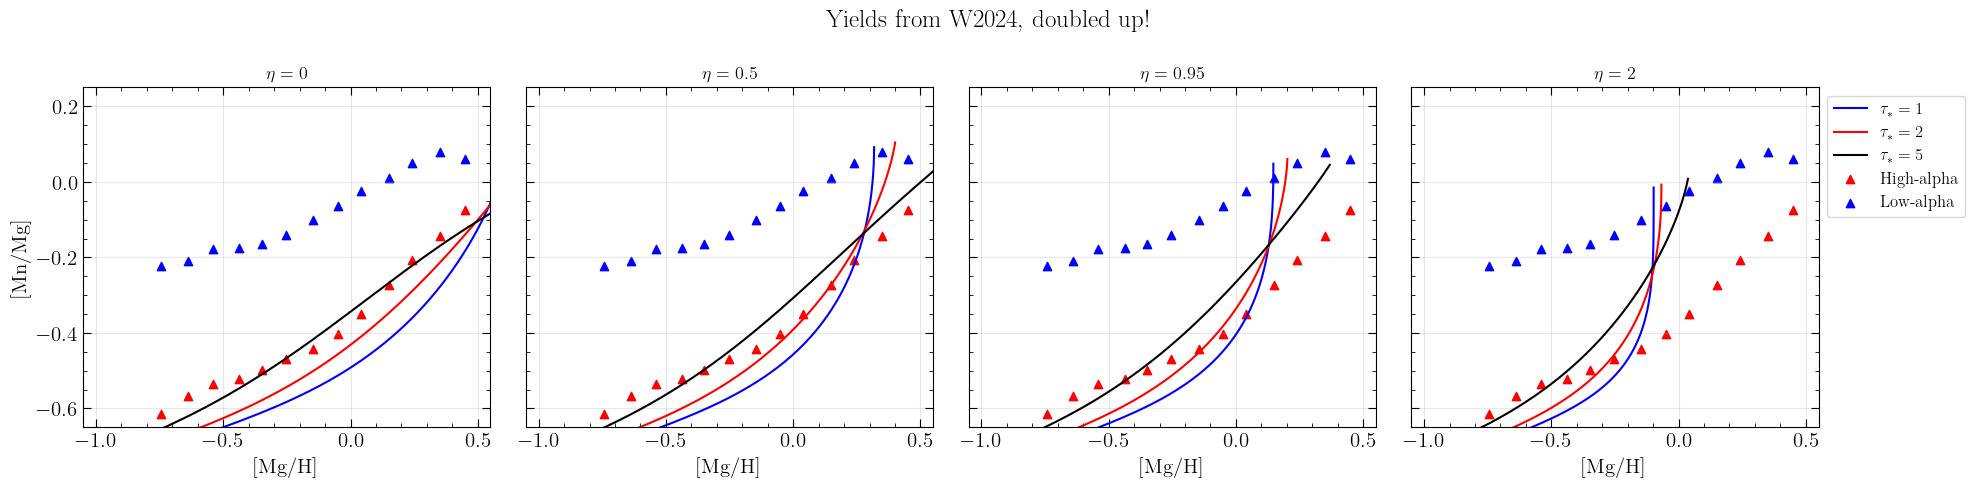

In [26]:
etas = [0, 0.5, 0.95, 2]
tau_stars = [1, 2, 5]
#tau_sfhs = [3, 6, 10]
#tau_Ias = [0.5, 1.5, 3]
linestyles = ['-']
colors = ['blue', 'red', 'black', 'green', 'magenta']

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for i, eta in enumerate(etas):
    ax = axes[i]
    for j, taustar in enumerate(tau_stars):
        clr = colors[j % len(colors)]
        lstyle = linestyles[j % len(linestyles)]
        for tau_sfh in tau_sfhs:
            for tau_Ia in tau_Ias:
                gal_temp = evo.Galaxy(
                    t_array=t_array,
                    m_g_array=1 * np.exp(-t_array/tau_sfh),
                    eta=eta,
                    tau_star=taustar,
                    yields_ref="W2024,double"
                )
                label = rf"$\tau_* = {taustar}$"
                ax.plot(
                    gal_temp.Mg_H[1:], gal_temp.Mn_Mg[1:], 
                    label=label, color=clr, linestyle=lstyle
                )

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    if i == 3:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)


plt.suptitle("Yields from W2024, doubled up!")
plt.tight_layout()
plt.show()


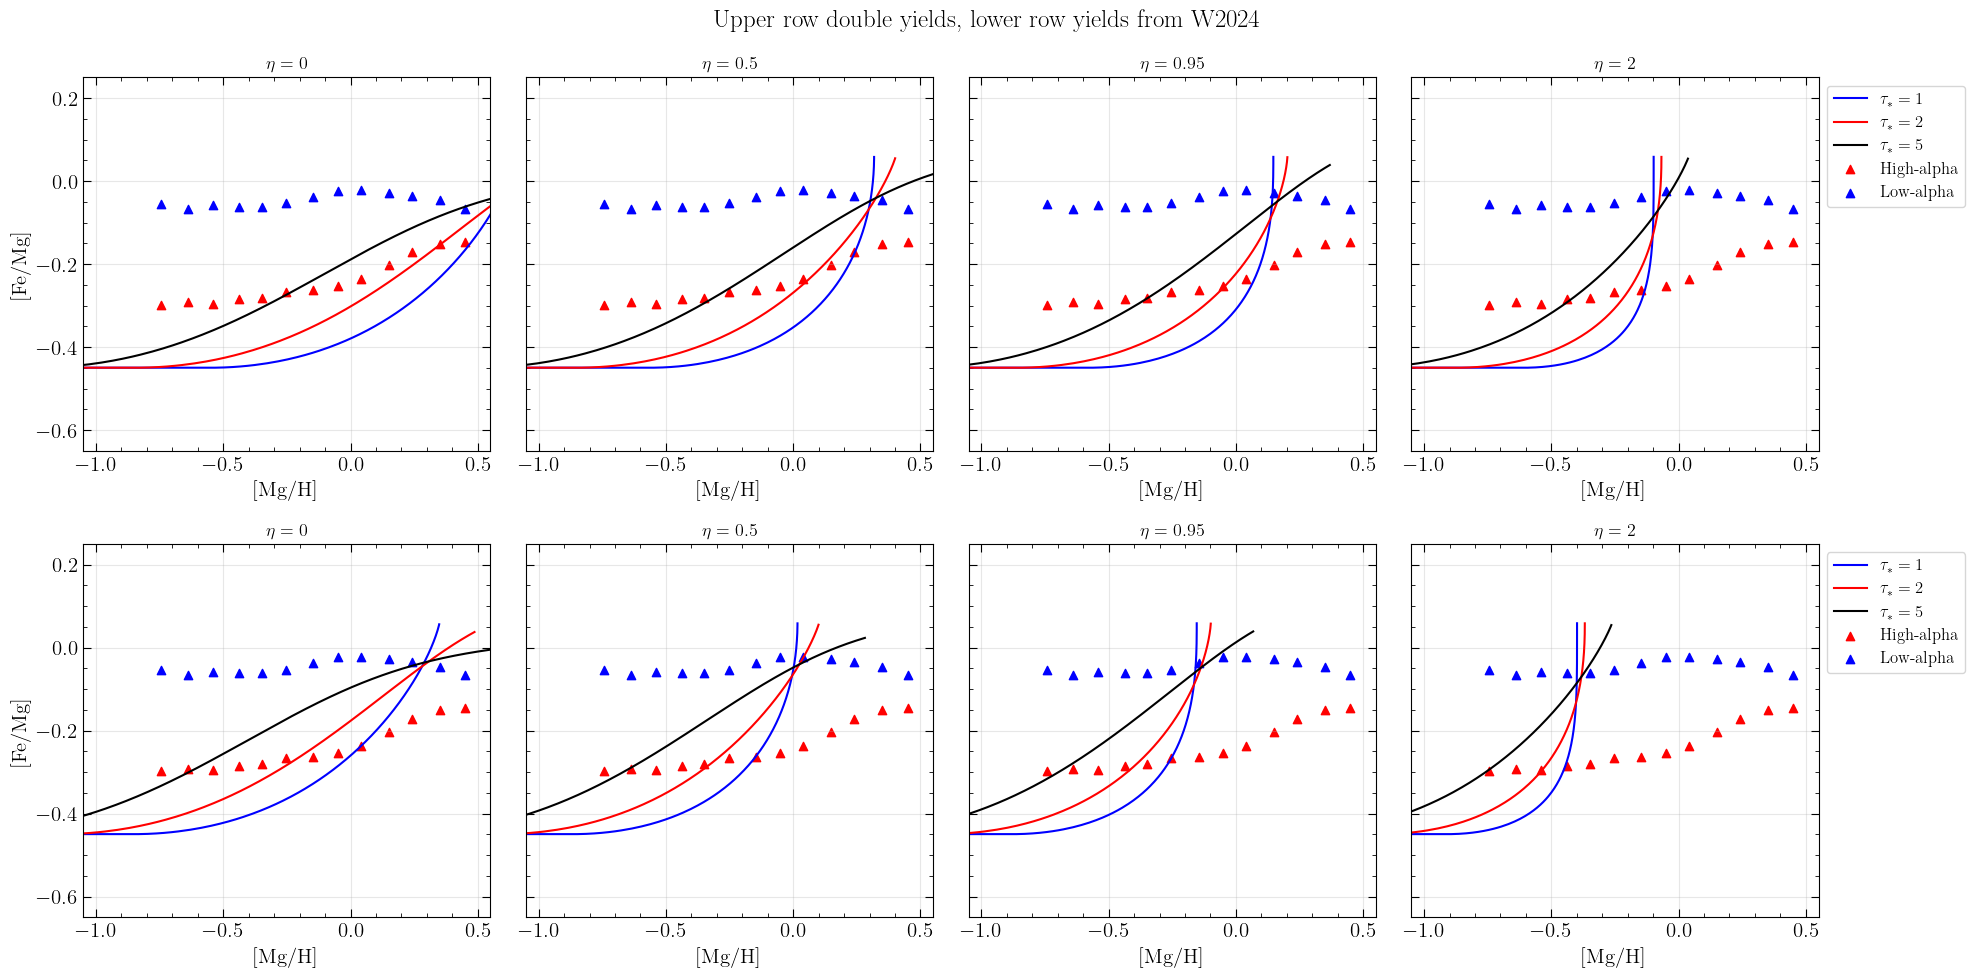

In [27]:
etas = [0, 0.5, 0.95, 2]
tau_stars = [1, 2, 5]
#tau_sfhs = [3, 6, 10]
#tau_Ias = [0.5, 1.5, 3]
linestyles = ['-']
colors = ['blue', 'red', 'black', 'green', 'magenta']

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True)

for i, eta in enumerate(etas):
    ax = axes[0][i]
    for j, taustar in enumerate(tau_stars):
        clr = colors[j % len(colors)]
        lstyle = linestyles[j % len(linestyles)]
        for tau_sfh in tau_sfhs:
            for tau_Ia in tau_Ias:
                gal_temp = evo.Galaxy(
                    t_array=t_array,
                    m_g_array=1 * np.exp(-t_array/tau_sfh),
                    eta=eta,
                    tau_star=taustar,
                    yields_ref="W2024,double"
                )
                label = rf"$\tau_* = {taustar}$"
                ax.plot(
                    gal_temp.Mg_H[1:], gal_temp.Fe_Mg[1:], 
                    label=label, color=clr, linestyle=lstyle
                )

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H]')
    if i == 0:
        ax.set_ylabel('[Fe/Mg]')
    if i == 3:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)


for i, eta in enumerate(etas):
    ax = axes[1][i]
    for j, taustar in enumerate(tau_stars):
        clr = colors[j % len(colors)]
        lstyle = linestyles[j % len(linestyles)]
        for tau_sfh in tau_sfhs:
            for tau_Ia in tau_Ias:
                gal_temp = evo.Galaxy(
                    t_array=t_array,
                    m_g_array=1 * np.exp(-t_array/tau_sfh),
                    eta=eta,
                    tau_star=taustar,
                    yields_ref="W2024"
                )
                label = rf"$\tau_* = {taustar}$"
                ax.plot(
                    gal_temp.Mg_H[1:], gal_temp.Fe_Mg[1:], 
                    label=label, color=clr, linestyle=lstyle
                )

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H]')
    if i == 0:
        ax.set_ylabel('[Fe/Mg]')
    if i == 3:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)


plt.suptitle("Upper row double yields, lower row yields from W2024")
plt.tight_layout()
plt.show()


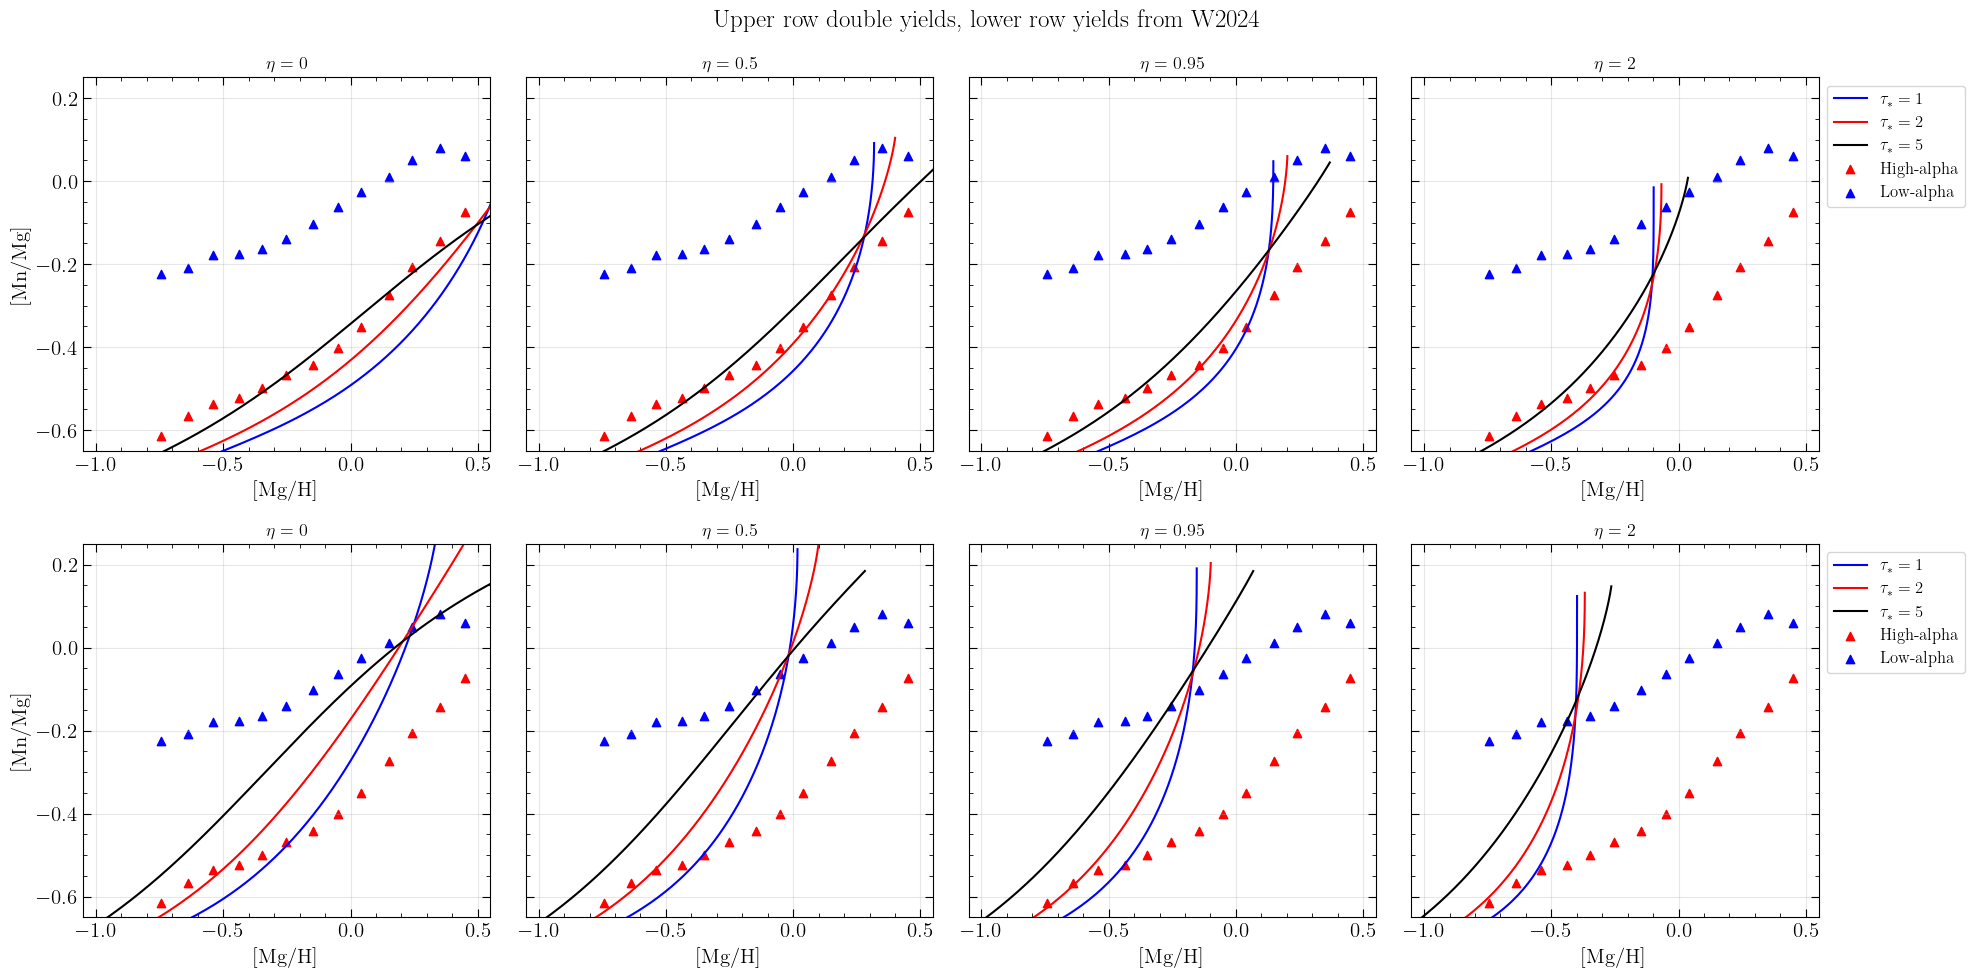

In [28]:
etas = [0, 0.5, 0.95, 2]
tau_stars = [1, 2, 5]
#tau_sfhs = [3, 6, 10]
#tau_Ias = [0.5, 1.5, 3]
linestyles = ['-']
colors = ['blue', 'red', 'black', 'green', 'magenta']

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True)

for i, eta in enumerate(etas):
    ax = axes[0][i]
    for j, taustar in enumerate(tau_stars):
        clr = colors[j % len(colors)]
        lstyle = linestyles[j % len(linestyles)]
        for tau_sfh in tau_sfhs:
            for tau_Ia in tau_Ias:
                gal_temp = evo.Galaxy(
                    t_array=t_array,
                    m_g_array=1 * np.exp(-t_array/tau_sfh),
                    eta=eta,
                    tau_star=taustar,
                    yields_ref="W2024,double"
                )
                label = rf"$\tau_* = {taustar}$"
                ax.plot(
                    gal_temp.Mg_H[1:], gal_temp.Mn_Mg[1:], 
                    label=label, color=clr, linestyle=lstyle
                )

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    if i == 3:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)


for i, eta in enumerate(etas):
    ax = axes[1][i]
    for j, taustar in enumerate(tau_stars):
        clr = colors[j % len(colors)]
        lstyle = linestyles[j % len(linestyles)]
        for tau_sfh in tau_sfhs:
            for tau_Ia in tau_Ias:
                gal_temp = evo.Galaxy(
                    t_array=t_array,
                    m_g_array=1 * np.exp(-t_array/tau_sfh),
                    eta=eta,
                    tau_star=taustar,
                )
                label = rf"$\tau_* = {taustar}$"
                ax.plot(
                    gal_temp.Mg_H[1:], gal_temp.Mn_Mg[1:], 
                    label=label, color=clr, linestyle=lstyle
                )

    # Add the scatter points for observed data
    ax.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], 
               marker='^', color='red', label='High-alpha')
    ax.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], 
               marker='^', color='blue', label='Low-alpha')

    # Customize subplot
    ax.set_title(rf"$\eta = {eta}$", fontsize=13)
    ax.set_xlim(-1.05, 0.55)
    ax.set_ylim(-0.65, 0.25)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('[Mg/H]')
    if i == 0:
        ax.set_ylabel('[Mn/Mg]')
    if i == 3:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)


plt.suptitle("Upper row double yields, lower row yields from W2024")
plt.tight_layout()
plt.show()
